In [1]:
# Use ve3PaleoSTeHM environment

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
# Load modules
import matplotlib.pyplot as plt # Used for plotting 
import matplotlib
import numpy as np # Used for numerical computations
import pandas as pd # For handling tabular data 
import xarray as xr #For working with labeled multi-dimensional arrays 
import os

# Import statistical and optimization tools
from scipy.stats import norm
from scipy import interpolate
from scipy.interpolate import BSpline # For spline fitting 
from scipy.stats import norm, multivariate_normal
from scipy.optimize import curve_fit
from scipy.io import loadmat # For reading MatLab files 
from scipy.optimize import minimize
from scipy.interpolate import UnivariateSpline
from scipy.odr import ODR, Model, RealData # For orthogonal distance regression 

# Matplotlib configuration for advanced plotting 
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from matplotlib import cm
from matplotlib import colors as mcolors
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

# Importing colormap 
import cmocean.cm as cmo
import cmocean as cmo

# System utilities 
import sys
# sys.path.append('../../')
import time

# Import Cartopy for map projections and geographic visualizations 
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# For geospatial and statistical processing 
import pyproj
import statsmodels.api as sm
import geopandas as gpd
import rioxarray

# Importing polartoolkit
from polartoolkit import fetch, maps, regions

# Linear algebra tools 
from numpy.linalg import lstsq

# Machine learning libraries 
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import DBSCAN
from sklearn.utils import resample
from util import * 

# Bootstrap and BSpline functions 
import numpy as np
from astropy.stats import bootstrap
from scipy.interpolate import BSpline

#pyro.set_rng_seed(0) #set random seed used in this notebook

# Setting plotting style 
%matplotlib inline
font = {'weight':'normal',
       'size':22,
       'family':'Helvetica'}
matplotlib.rcParams['xtick.major.size'] = 20
matplotlib.rcParams['ytick.major.size'] = 20
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['legend.frameon'] = 'True'
matplotlib.rc('font',**font)

# Turn off warnings 
import warnings
warnings.filterwarnings("ignore")

# Custom fonts for plots 
f1 = 30
f2 = 24
f3 = 20

# Define utility function for replacing nth occurence of a substring 
def replace_nth(txt, sub,repl,nth):
    arr=txt.split(sub)
    part1=sub.join(arr[:nth])
    part2=sub.join(arr[nth:])
    return part1+repl+part2

# Function to prepare data arrays for plotting and analysis 
def make_data_xy(grp):
    grp['elv_zero_st'] = grp.elv_comp 
    grp['elv_err_st'] = grp.elv_err
    grp = grp.sort_values('age') # Sort by age 
    x = grp.age.values[::-1].astype(float) * -1 # np.round(grp.age * 2, -1) / 2 # Reverse and negate ages
    y = grp.elv_zero_st.values[::-1].astype(float) # Reverse elevations 
    yerr = grp.elv_err_st.values[::-1].astype(float) # Reverse elevation errors 
    xerr = grp.age_err.values[::-1].astype(float) # Reverse age errors 
    return x, y, xerr, yerr

# Function to prepare data arrays for plotting and analysis 
# del plot_uncertainty_boxes, plot_tem_regression
def plot_uncertainty_boxes(x, y, x_error, y_error, ax=None, alpha=1, lw=3,
                           fc=(1,0.82,0.86,0.15), ec=(0.7,0,0,0.7), zorder=2):
    '''
    A function to plot uncertainty box for data with vertical and horizontal uncertainties.

    -----------------Input-------------------
    x: a 1-D array of input data
    y: a 1-D array of ouput data
    x_error: a 1-D array containing 2 sigma uncertainty of input data
    y_error: a 1-D array containing 2 sigma uncertainty of output data

    ---------------Return-------------------
    ax: a matplotlib ax of output plot
    '''
    if ax == None: ax = plt.subplot(111)
    for i in range(len(x)):
        ax.add_patch(plt.Rectangle((x[i] - x_error[i], y[i] - y_error[i]), 2 * x_error[i], 2 *  y_error[i], 
                                    fill=True, fc=fc,ec=ec, linewidth=lw, zorder=zorder, alpha=alpha))

    ax.set_xlabel('Age (BP)')
    ax.set_ylabel('Elevation above \npresent-day ice (m)')
    return ax

# Function to plot temporal regression results 
def plot_tem_regression(data_age, data, data_age_sigma, data_elv_sigma, mean_age, mean_elv,
                        lower_bound, upper_bound, mean_rate, lower_bound_rate, upper_bound_rate,
                        name, color='C0', fig=None, axes=None, yhi=0, xhi=0, LGM_lim=0,
                       placename=''):
    '''
    A function to create matplotlib plot for temporal regression results.

    -----------------Inputs-------------------
    data_age: a 1-D array of rsl age data
    data_rsl: a 1-D array of rsl data
    data_age_sigma: a 1-D array containing 1 sigma uncertainty of rsl age data
    data_rsl_sigma: a 1-D array containing 1 sigma uncertainty of rsl data
    mean_rsl_age: a 1-D array of testing age data, i.e., new_X for GP regression
    mean_rsl: a 1-D array of mean rsl regression results
    rsl_sd: a 1-D array of rsl regression standard deviation
    rsl_rate_age: a 1-D array of testing age data for rsl rate
    rsd_rate: a 1-D array of mean rsl rate regression results
    rate_sd: a 1-D array of rsl rate regression standard deviation
    axes: matplotlib axes, if None, create a new figure
    save: bool, whether to save the plot

    ---------------Output-------------------
    A matplotlib plot of temporal regression results which contains
    three sub-plots: 1) RSL data with uncertainty box and mean regression line; 2) RSL rate
    with uncertainty box and mean regression line; 3) Residual plot.


    '''

    if len(axes) < 1:
        fig, axes = plt.subplots(nrows=1,
                                    ncols=2,
                                    figsize=(36, 12)
                                    )
    # Left output subplot: data with uncertainty boxes 
    ax = axes[0]
    plot_uncertainty_boxes(data_age,
                            data,
                            data_age_sigma * 2,
                            data_elv_sigma * 2,
                            ax=ax,
                           lw=0.3,
                           fc='none',
                           ec='k',
                           alpha=1,
                           zorder=2
                            )
    
    plot_uncertainty_boxes(data_age,
                            data,
                            data_age_sigma * 2,
                            data_elv_sigma * 2,
                            ax=ax,
                           fc=color,
                           ec='k',
                           alpha=0.1,
                           zorder=1
                            )
    # Right output subplot: data with uncertainty boxes
    plot_uncertainty_boxes(data_age,
                            data,
                            data_age_sigma * 2,
                            data_elv_sigma * 2,
                            ax=ax,
                           fc='w',
                           ec='w',
                           alpha=1,
                           zorder=0
                            )

    ax.plot(mean_age,mean_elv,linewidth=3,zorder=11,color='k',)
    ax.plot(mean_age,lower_bound,linewidth=1,zorder=11,color='k')
    ax.plot(mean_age,upper_bound,linewidth=1,zorder=11,color='k')
    ax.fill_between( mean_age, lower_bound, upper_bound, color=color, alpha=0.4, zorder=10, label=placename)
    ax.fill_between(mean_age, lower_bound,upper_bound,color='w',alpha=1, zorder=9)
    ylo = np.minimum(-10, np.min(data) - np.mean(data_elv_sigma) * 2)
    xhi = np.maximum(xhi, np.max(data_age) + np.mean(data_age_sigma) * 2 + 300)
    ax.set_ylim(ylo, yhi)
    ax.set_xlim(0, xhi)
    # ax.set_xlim(0, 20000)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.3)

    # PLot the LGM limit-assigned in 'icedcurrent_v14_EM.xlsx'
    if LGM_lim > 0:
        ax.axhline(LGM_lim, color=color, ls='--', label=f'{placename} Local LGM Limit')
    
    
    ####### RATE PLOT ##########
    ax = axes[1]

    ax.plot(mean_age,
            mean_rate,
            linewidth=3,
            color=color,
            )
    
    ax.fill_between(mean_age,
                    lower_bound_rate,
                    upper_bound_rate,
                    linewidth=3,
                    label=placename,
                    color=color,
                    alpha=0.3,
                )

    # Get xlim from previous plots in case those are already set
    _, yhi_rate = ax.get_ylim()
    _, xhi_rate = ax.get_xlim()

    yhi_rate = np.maximum(yhi_rate, np.nanmax(upper_bound_rate) + 5)
    # yhi_rate = np.minimum(yhi_rate, 200)

    ### ADD DUMMY LINE FOR LEGEND ###
    if LGM_lim > 0:
        lgmname = placename.split(':')[0]
        ax.axhline(-100, color=color, ls='--', label=f'{lgmname} Local LGM Limit')

    ax.grid(alpha=0.3)
    ax.set_xlim(0, xhi)
    # ax.set_xlim(0, 20000)

    ax.set_ylim(-5, yhi_rate)
    ax.axhline(0, color='k', lw=1)
    
    ax.set_xlabel('Age (ka)')
    ax.set_ylabel('Rate of ice thinning (m/kyr)')
    ax.legend(loc='best')

    # Add titles and return figure 
    fig.suptitle(f'Site {name}')
    return fig, axes


print('done')

done


# Available Sensitivity Tests

In [23]:
# | **Test** | **Effect** | **Where Used** | **Notes** |
# |----------|------------|----------------|-----------|
# | **C1b**  | Use weighted mean of Al/Be even if discordant                  | `load_data()` | Overrides default discordance logic |
# | **C1c**  | Use youngest Al/Be age at stratigraphic level                  | `load_data()` | Prioritizes youngest signal |
# | **C3a**  | Elevation error = max(2 m, 1%)                                 | `load_data()` | Less conservative vertical uncertainty |
# | **C3b**  | Elevation error = max(7.5 m, 3%)                               | `load_data()` | Moderate uncertainty assumption |
# | **C3c**  | Elevation error = max(10 m, 4%)                                | `load_data()` | Most conservative of the three |
# | **C11**  | Use **internal** (not external) age uncertainty (`dtint_LSDn`) | `load_data()` | Assumes different error model |
# | **C4a**  | Fewer spline knots (`+1`)                                 | `run_bayesian_spline()` | Least flexible spline |
# | **C4b**  | More knots (`+5`)                                         | `run_bayesian_spline()` | Moderately flexible spline |
# | **C4c**  | Many knots (`+10`)                                        | `run_bayesian_spline()` | Most flexible spline |
# | **C10a** | Low proposal scale = 10                                   | `run_bayesian_spline()` | Slower MCMC tuning, fine-grained |
# | **C10b** | Proposal scale = 100                                      | `run_bayesian_spline()` | Faster but broader steps |
# | **C10c** | Proposal scale = 200                                      | `run_bayesian_spline()` | Very fast proposals, less stability |
# | **C5a**  | Turns off **Ry** (fit-to-data penalty)                       | `log_likelihood()` | Ignores stratigraphy/spline match |
# | **C5b**  | Ry = 10 (stronger data-fit penalty)                          | `log_likelihood()` | Tighter fit requirement |
# | **C5c**  | Ry = 100 (very strict)                                       | `log_likelihood()` | Aggressive stratigraphic enforcement |
# | **C6a**  | Reduces **Ru** (monotonic penalty) to 1                      | `log_likelihood()` | Allows more curvature |
# | **C6b**  | Ru = 100                                                     | `log_likelihood()` | Enforces stronger monotonic thinning |
# | **C6c**  | Ru = 1000                                                    | `log_likelihood()` | Very strict monotonicity |
# | **C7a**  | Removes **Rh** (highest elevation at oldest)                 | `log_likelihood()` | No peak-age constraint |
# | **C7b**  | Rh = 10                                                      | `log_likelihood()` | Stronger penalty if peak not at oldest age |
# | **C7c**  | Rh = 100                                                     | `log_likelihood()` | Very strict peak-age enforcement |
# | **C8a**  | Removes **Rb** (minimum elevation at youngest)               | `log_likelihood()` | No thinning-to-present constraint |
# | **C8b**  | Rb = 10                                                      | `log_likelihood()` | Stronger thinning constraint |
# | **C8c**  | Rb = 100                                                     | `log_likelihood()` | Enforces thinning strongly at modern age |

In [24]:
# Will carry these tests through the rest of the script
SENSITIVITY_TEST = 'C10a'

# Bayesian Spline and Bootstrapping Functions 

In [25]:
import numpy as np
from astropy.stats import bootstrap
from scipy.interpolate import BSpline
# Checks if all pairs of age ranges in the Datafram overlap. Returns True if all pairs overlap, false otherwise. 

# Define number of samples globally
N_BOOTSTRAP_SAMPLES = 1000
N_POSTERIOR_SAMPLES = 1000

n_samples = N_BOOTSTRAP_SAMPLES  # for shaping output arrays and plotting

def check_pairwise_overlap(df):
    # Iterate through each row in the DataFrame 
    for i in range(len(df)):
        age_i = abs(df.iloc[i]['age'])
        sigma_i = df.iloc[i]['dtint_LSDn']
        lower_i = age_i - 2 * sigma_i
        upper_i = age_i + 2 * sigma_i
        
        # Compare it with every other row
        for j in range(i + 1, len(df)):
            age_j = abs(df.iloc[j]['age'])
            sigma_j = df.iloc[j]['dtint_LSDn']
            lower_j = age_j - 2 * sigma_j
            upper_j = age_j + 2 * sigma_j
            
            # Check if there's no overlap between the two ranges
            if upper_i < lower_j or upper_j < lower_i:
                return False  # No overlap between at least one pair

    return True  # All data pairs overlap

# Calcylates weights inversely proporitonal to age errors 
def take_weighted_mean(grp):

    wts = (1 / grp.age_err) / (1/grp.age_err).sum()

    # Compute the weighted mean age 
    grp['age'] = (grp.age * wts).sum()
    # Use the mean age error
    grp['age_err'] = grp.age_err.mean()
    # Use the mean elevation and elevation error 
    grp['elv_comp'] = grp.elv_comp.mean()
    grp['elv_err'] = grp.elv_err.mean()

    return grp.drop_duplicates('age')

# Load and preprocesses dara from an Excel file
def load_data(path, SENSITIVITY_TEST=SENSITIVITY_TEST):
    data = pd.read_excel(path)

    # Filter out ages outside of the 0-30,000 year range 
    data = data[(data.t_LSDn < 30000) & (data.t_LSDn > 0)].reset_index(drop=True) # & # (data.lon_DD < -100)
    
    # Round lat/lon to nearest degree to group data
    data[['latrnd', 'lonrnd']] = (data[['lat_DD','lon_DD']] * 2).apply(lambda x: pd.Series.round(x,0)) / 2

    # Get mean of each group's lat and lon
    grplat = data.groupby('Group')['lat_DD'].mean()
    grplon = data.groupby('Group')['lon_DD'].mean()

    # Round these lat/lons to nearest X% of a degree to enable plotting
    n = 0.05
    data['Group_lat'] = (data['Group'].map(grplat) * n).round(0) / n
    data['Group_lon'] = (data['Group'].map(grplon) * n).round(0) / n


    ####### USE Density-Based Spatial Clustering of Applications with Noise algorithm ######## 
    
    # Convert latitude and longitude to numpy array
    coords = data[['lat_DD', 'lon_DD']].to_numpy()
    
    # Set the maximum distance between two samples for them to be considered as in the same neighborhood
    epsilon = 0.75  # 5 degrees
    
    # Perform DBSCAN clustering
    db = DBSCAN(eps=epsilon, min_samples=1, metric='euclidean').fit(coords)
    
    # Add the cluster labels to the dataframe
    data['cluster'] = db.labels_

    ##################################################
    ######### convert to polar stereographic #########
    ##################################################
    
    target_crs  = 'epsg:3031' # Coordinate system of the file
    source_crs = 'epsg:4326' # Global lat-lon coordinate system
    
    latlon_to_polar = pyproj.Transformer.from_crs(source_crs, target_crs)
    
    x_DD, y_DD = latlon_to_polar.transform(data.lat_DD, data.lon_DD)
    data['x_DD'] = x_DD
    data['y_DD'] = y_DD
    data['t_LSDn'] = data['t_LSDn'] # / 1000
    data['age'] = data.t_LSDn * -1

    data['age_err'] = data.dtext_LSDn # / 1000

    if SENSITIVITY_TEST == 'C11':
        data['age_err'] = data.dtint_LSDn # / 1000

    # Round ages to nearest 5
    data['age'] = np.round(data.age * 2, -1) / 2
    
    ##### Get vertical error #######
    # assign 1% of elevational uncertainty to data without vertical uncertainties
    def get_errs(x):
        
        if SENSITIVITY_TEST == 'C3a':
            return np.maximum(2, 0.01 * x)
            
        if SENSITIVITY_TEST == 'C3b':
            return np.maximum(7.5, 0.03 * x)
            
        if SENSITIVITY_TEST == 'C3c':
            return np.maximum(10, 0.04 * x)
            
        return np.maximum(10, 0.05 * x)

    
    elv_err = data.elv_m.map(get_errs)

    # If errs exist, choose those, otherwise, choose at least 5 m or 1% (or sensitivity test) of elevation
    data['elv_err'] = np.minimum(data.elv_m_err_1std.fillna(100000), elv_err)
    
    # If data have relative elevation, use that.  Otherwise, use elevation as given 
    rel_elv = data['rel_elv_m']
    data['elv_comp'] = rel_elv.fillna(data['elv_m'])
    
    # Drop rejected data
    data_in = data.copy()
    data = data_in[data_in.Reject < 1]

    ######### REMOVE CHLORINE AND HELIUM DATA ##########
    
    # Drop chlorine and helium data
    data = data[data.cosmo_type != 'Cl']
    data = data[data.cosmo_type != 'He']
    
    # make sure 'e' and 'Bee' count as 'Be'
    data['cosmo_type'] = data.cosmo_type.replace('e', 'Be')
    data['cosmo_type'] = data.cosmo_type.replace('Bee', 'Be')
    # Drop useless columns
    data = data.drop(['thick_cm', 'density', 'what', 'N10_atoms_g', 'delN10_atoms_g', 'N26_atoms_g', 'delN26_atoms_g', 'Notes-1'], axis=1)
    
    # Drop any pre-9 ka data that are lower than 9 ka data
    datas = []
    for name, grp in data.groupby('Group'):
        # Get maximum for lower than 9 ka
    
        # if grp.t_LSDn.min() < 9000:
    
        # Get the highest age at or before 11.8 ka
        splitage = 11700
        data_yng = grp[grp.t_LSDn < splitage]
        data_old = grp[grp.t_LSDn >= splitage]
        
        if len(data_old) > 0:
    
            # Get age of maximum value for young part of dataset
            ageofmax = data_yng[data_yng.elv_comp == data_yng.elv_comp.max()].t_LSDn.mean()
            
            max_yng = data_yng.elv_comp.max()
            min_yng = data_yng.elv_comp.min()


            #  Only keep pre-Hol data if they are higher than the Hol max
            data_old = data_old[data_old.elv_comp >= max_yng]
            
        datas.append(data_yng)
        datas.append(data_old)
    
        print(str(name), end=' ')
        # if len(data_hi) >5:
        #     break
        # if '89' in str(name):
        #     break
    
    data = pd.concat(datas, axis=0)

    #############################################
    ##### SELECT DATA BASED ON C/BE/Al #########

    # iterate through groups

    savegrps=[]
    for i, (_, grp) in enumerate(data.groupby('Group')):
        
        # For a single elevation
        for elv, elvgrp in grp.groupby('elv_comp'):
        
            # Split group into C dates, Al/Be dates, and just Be dates
            grp_c = elvgrp[elvgrp.cosmo_type == 'C']
            grp_AlBe = elvgrp[elvgrp.cosmo_type != 'C']
            grp_Be = elvgrp[elvgrp.cosmo_type == 'Be']
            
            # Ff oldest C is younger than Be/Al, take weighted mean of C
            if len(grp_c) > 0:
                
                # Get oldest carbon age -- sorted in case there are more than one
                oldest_c = grp_c.sort_values('age').iloc[[0]]

                # Only check carbon if there's an alternative
                if len(grp_AlBe) > 0:
                    # check whether oldest carbon age is younger than youngest non-carbon age
                    if (abs(oldest_c.age.values) - abs(grp_AlBe.age.values)).max() < 0:
                        print('C', end=', ')
                        savegrp = grp_c
                        
                # Otherwise just use carbon
                else:
                    savegrp = grp_c
                
            # Otherwise, only work with Be/Al ages
            else:
                # Check whether there is only one datum
                if (len(grp_AlBe) == 1):
                    print('1', end=',')
                    savegrp = grp_AlBe
        
                else:
                    # If data are concordant, take weighted mean of Al/Be
                    if check_pairwise_overlap(grp_AlBe):
                        print('concordant', end=',')
                        savegrp = take_weighted_mean(grp_AlBe)
                
                    # If not, take weighted means only of Be
                    else:
                        print('Be', end=',')
                        savegrp = take_weighted_mean(grp_Be)
                
                # Test always doing weighted mean of Al/Be even if discordant
                if SENSITIVITY_TEST == 'C1b':
                    savegrp = take_weighted_mean(grp_AlBe)
                    
                # Test always doing taking youngest age at stratigraphic level
                if SENSITIVITY_TEST == 'C1c':
                    savegrp = grp_AlBe.sort_values('age').iloc[[-1]]

            savegrps.append(savegrp)
            
    data = pd.concat(savegrps)


    # Any data below zero are at ice level
    data['elv_comp'] = data['elv_comp'].mask(data['elv_comp'] <= 0, 0.1)

    # Add column for only oldest DOI, as this will be shared if multiple DOIs 
    data['DOI_oldest'] = data.DOI.str.split(',').str[0]

    ####### WEIGHT CLUSTERS BY NUMBER OF SITES ########
    # Calculate cluster weights inversely propotional to the number of unique groups 
    cluster_weights = 1 / data.groupby(['cluster'])['Group'].nunique()
    cluster_weights = cluster_weights / cluster_weights.sum()
    
    data['cluster_weights'] = data['cluster'].map(cluster_weights)

    # Get all rejected data
    idx = data_in.index[~data_in.index.isin(data.index)].dropna()
    data_rejected = data_in.loc[idx]
    return data_in, data, data_rejected

# Runs a Bayesian spline model to fit elevation data over time
def run_bayesian_spline(ages, age_uncertainties, elevations, elevation_uncertainties, 
                            n_samples=1000, SENSITIVITY_TEST=SENSITIVITY_TEST, xstep=5):
        
    # Spline order
    degree = 3
    # num = len(ages) + degree - 1
    num = len(ages) + degree 
    if SENSITIVITY_TEST == 'C4a':
        num = len(ages) + 1
    if SENSITIVITY_TEST == 'C4b':
        num = len(ages) + 5
    if SENSITIVITY_TEST == 'C4c':
        num = len(ages) + 10

    # Determine the number of knots based on sensitivity tests 
    knot_locs = np.linspace(ages.min(), ages.max(), num=num)  # Adjust knot locations
    
    # Create B-spline basis functions
    def create_bspline_basis(x, knots, degree):
        n_knots = len(knots)
        extended_knots = np.concatenate(([knots[0]] * degree, knots, [knots[-1]] * degree))
        basis = np.zeros((len(x), n_knots + degree - 1))
        for i in range(n_knots + degree - 1):
            coeff = np.zeros(n_knots + degree - 1)
            coeff[i] = 1
            spline = BSpline(extended_knots, coeff, degree)
            basis[:, i] = spline(x)
        return basis

    # Create B-spline basis matrix 
    B = create_bspline_basis(ages, knot_locs, degree)

    # ─────────── INSERTED BOOTSTRAP BLOCK ───────────
    # stack ages and their uncertainties for paired resampling
    # Determine knot locations
    knot_locs = np.linspace(ages.min(), ages.max(), num=num)

    # Create bootstrapped B-spline basis matrices
    data = np.vstack([ages, age_uncertainties]).T
    bootstrapped_data = bootstrap(data, bootnum=n_samples)

    bspline_basis_bootstrapped = []
    for i in range(n_samples):
        ages_i = bootstrapped_data[i, :, 0]
        basis_i = create_bspline_basis(ages_i, knot_locs, degree)
        bspline_basis_bootstrapped.append(basis_i)

    bspline_basis_bootstrapped = np.stack(bspline_basis_bootstrapped)  # shape: (n_samples, n_points, n_basis)

    # ───────── END BOOTSTRAP BLOCK ─────────
    
    # Initialize parameters
    coeffs = np.zeros(B.shape[1])
    N_samples = 3000
    burn_in = 1000
    
    # Storage for samples
    coeff_samples = np.zeros((n_samples, B.shape[1]))
    

        # Log likelihood function with soft constraints
    def log_likelihood(coeffs, SENSITIVITY_TEST=SENSITIVITY_TEST):
        mu = B @ coeffs
        # ll = -0.5 * np.sum(((elevations - mu) / elevation_uncertainties) ** 2)

        # Calculate the model ages corresponding to each data point
        model_ages = np.interp(elevations, mu, ages)

        # Calculate WRSS in age/elevation space
        age_residuals = (ages - model_ages) ** 2 / age_uncertainties ** 2
        elevation_residuals = (elevations - mu) ** 2 / elevation_uncertainties ** 2
        wrss = np.sum(age_residuals + elevation_residuals)
        
        ll = -0.5 * wrss

        # Scaling parameters for sensitivity tests
        Ry = 1
        Ru = .1 #was 10
        Rh = 1
        Rb = 1

        if 'a' in SENSITIVITY_TEST:
            if '5' in SENSITIVITY_TEST:
                Ry = 0
            if '6' in SENSITIVITY_TEST:
                Ru = 1
            if '7' in SENSITIVITY_TEST:
                Rh = 0
            if '8' in SENSITIVITY_TEST:
                Rb = 0 

        if 'b' in SENSITIVITY_TEST:
            if '5' in SENSITIVITY_TEST:
                Ry = 10
            if '6' in SENSITIVITY_TEST:
                Ru = 100
            if '7' in SENSITIVITY_TEST:
                Rh = 10
            if '8' in SENSITIVITY_TEST:
                Rb = 10 
                
        if 'c' in SENSITIVITY_TEST:
            if '5' in SENSITIVITY_TEST:
                Ry = 100
            if '6' in SENSITIVITY_TEST:
                Ru = 1000
            if '7' in SENSITIVITY_TEST:
                Rh = 100
            if '8' in SENSITIVITY_TEST:
                Rb = 100 
        
        # # Soft constraint: penalize if spline does not pass higher and younger than each datum
        # Soft_penalty = -np.sum(np.maximum(0, elevations - mu) ** 2) * 1e2

        # Soft constraint: penalize if spline does not pass higher and younger than each datum
        # Account for both age and elevation in the penalty and include uncertainties
        age_factor = (ages - ages.min()) / (ages.max() - ages.min())
        elevation_diff = elevations - mu
        age_scaled_diff = age_factor / age_uncertainties
        elevation_scaled_diff = elevation_diff / elevation_uncertainties
        soft_penalty = -np.sum(np.maximum(0, elevation_scaled_diff + age_scaled_diff) ** 2) * Ry
        
        # Soft constraint: penalize if coefficients are not non-decreasing
        non_decreasing_penalty = -np.sum(np.maximum(0, coeffs[:-1] - coeffs[1:]) ** 2) * Ru

        # # Soft constraint: penalize if the highest elevation is not at the age of the highest sample
        highest_sample_age = ages[np.argmax(elevations)]
        highest_elevation_penalty = -((mu[np.argmax(ages == highest_sample_age)] - elevations.max()) ** 2)  * Rh

        # # Soft constraint: penalize if the highest elevation is not at the oldest age
        # highest_elevation_penalty = -((mu[-1] - elevations.max()) ** 2) * 1e2
        
        #  # Soft constraint: penalize if the lowest elevation is not at the youngest age
        lowest_elevation_penalty = -((mu[0] - elevations.min()) ** 2)  * Rb

        return ll + soft_penalty + non_decreasing_penalty + highest_elevation_penalty + lowest_elevation_penalty

            
    # Metropolis-Hastings within Gibbs sampler
    proposal_scale = 60  # Standard deviation for the proposal distribution
    if SENSITIVITY_TEST == 'C10a':
        proposal_scale = 10
    if SENSITIVITY_TEST == 'C10b':
        proposal_scale = 100
    if SENSITIVITY_TEST == 'C10c':
        proposal_scale = 200

    # Sampling loop
    for i in range(n_samples + burn_in):
        for j in range(len(coeffs)):
            current_coeff = coeffs[j]
            
            # Propose a new value
            proposed_coeff = current_coeff + np.random.normal(0, proposal_scale)
            
            # Compute the log likelihood for the current and proposed coefficients
            coeffs[j] = proposed_coeff
            proposed_log_likelihood = log_likelihood(coeffs, SENSITIVITY_TEST=SENSITIVITY_TEST)
            coeffs[j] = current_coeff
            current_log_likelihood = log_likelihood(coeffs, SENSITIVITY_TEST=SENSITIVITY_TEST)
            
            # Compute the acceptance probability
            log_acceptance_ratio = proposed_log_likelihood - current_log_likelihood
            acceptance_ratio = np.exp(log_acceptance_ratio)
            
            # Accept or reject the proposal
            if np.random.rand() < acceptance_ratio:
                coeffs[j] = proposed_coeff
        
        if i >= burn_in:
            coeff_samples[i - burn_in] = coeffs
    
    # Compute mean and credible intervals
    coeff_mean = np.mean(coeff_samples, axis=0)
    coeff_lower = np.percentile(coeff_samples, 2.5, axis=0)
    coeff_upper = np.percentile(coeff_samples, 97.5, axis=0)
    
    # High-resolution age grid
    ages_high_res = np.arange(ages.min()-xstep, ages.max()+xstep, xstep)

    # Create high-resolution B-spline basis functions
    B_high_res = create_bspline_basis(ages_high_res, knot_locs, degree)

    # Evaluate the spline on the high-resolution grid for each posterior sample
    spline_samples_high_res = B_high_res @ coeff_samples.T
    
    # Compute mean and credible intervals on the high-resolution grid
    spline_mean_high_res = np.mean(spline_samples_high_res, axis=1)
    spline_lower_high_res = np.percentile(spline_samples_high_res, 2.5, axis=1)
    spline_upper_high_res = np.percentile(spline_samples_high_res, 97.5, axis=1)
    
    # Derivative of B-spline basis functions
    def create_bspline_basis_derivative(x, knots, degree):
        n_knots = len(knots)
        extended_knots = np.concatenate(([knots[0]] * degree, knots, [knots[-1]] * degree))
        basis_derivative = np.zeros((len(x), n_knots + degree - 1))
        for i in range(n_knots + degree - 1):
            coeff = np.zeros(n_knots + degree - 1)
            coeff[i] = 1
            spline = BSpline(extended_knots, coeff, degree)
            basis_derivative[:, i] = spline.derivative()(x)
        return basis_derivative
    
    B_derivative_high_res = create_bspline_basis_derivative(ages_high_res, knot_locs, degree)
    
    # Compute the rate of change (derivative of the spline) on the high-resolution grid
    rate_of_change_samples_high_res = B_derivative_high_res @ coeff_samples.T
    
    # Compute mean and credible intervals for the rate of change
    rate_mean_high_res = np.mean(rate_of_change_samples_high_res, axis=1)
    rate_lower_high_res = np.percentile(rate_of_change_samples_high_res, 2.5, axis=1)
    rate_upper_high_res = np.percentile(rate_of_change_samples_high_res, 97.5, axis=1)


    return ages_high_res, spline_mean_high_res, spline_lower_high_res, spline_upper_high_res, spline_samples_high_res, \
            rate_mean_high_res, rate_upper_high_res, rate_lower_high_res, rate_of_change_samples_high_res


# Regression and Plotting  

C10a
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 75 76 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 concordant,concordant,concordant,1,1,1,1,1,concordant,concordant,concordant,concordant,concordant,Be,concordant,concordant,concordant,1,1,concordant,concordant,1,concordant,concordant,concordant,1,1,Be,concordant,concordant,Be,concordant,1,1,concordant,concordant,concordant,concordant,concordant,1,1,1,concordant,concordant,1,concordant,1,concordant,1,1,concordant,1,concordant,1,1,1,concordant,concordant,1,concordant,concordant,concordant,concordant,concor

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 500 and the array at index 1 has size 1000

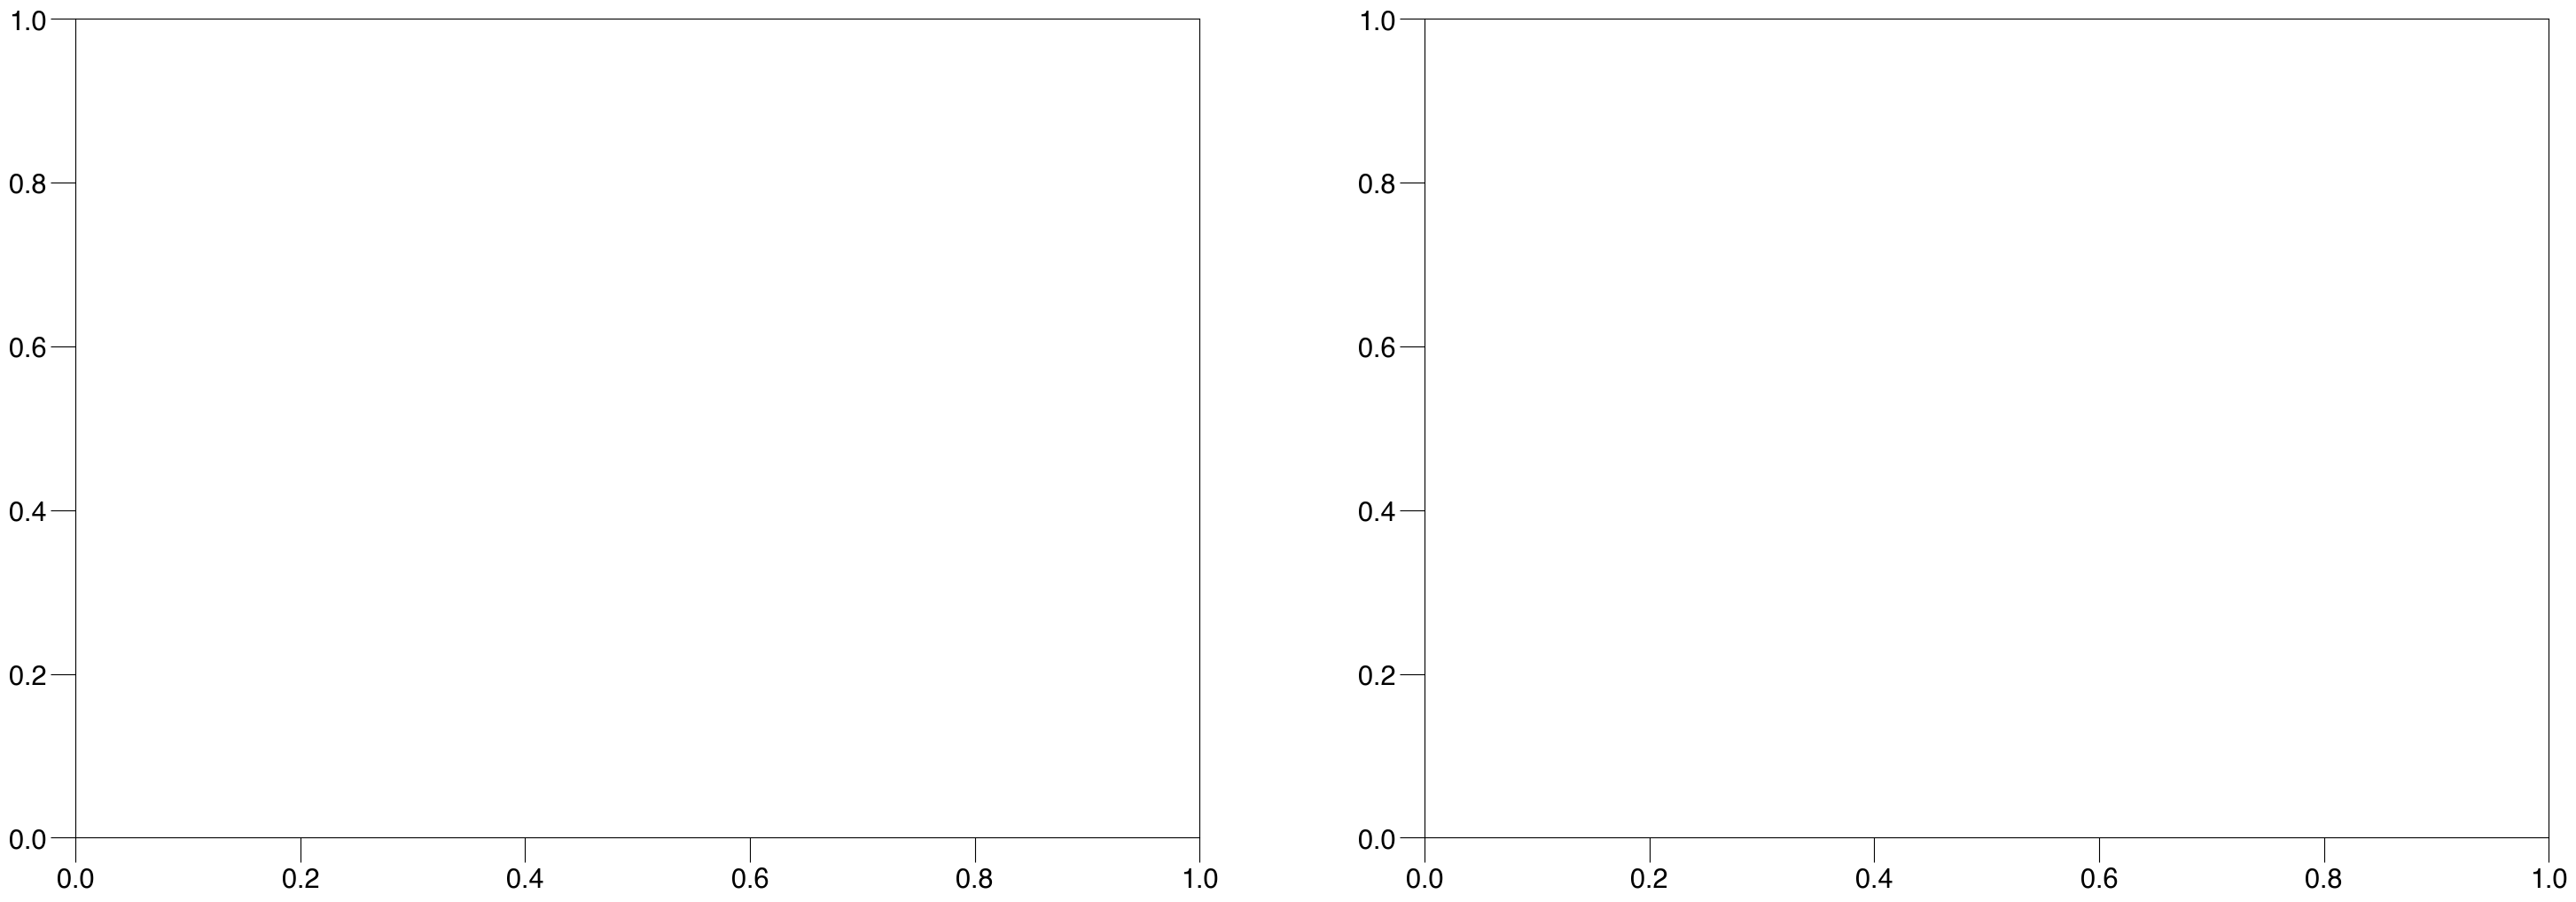

In [26]:
def plot_tem_regression(x, y, xerrs, yerrs,
                        ages_post, elv_post, elv_lo_bound, elv_hi_bound,
                        elv_rate_post, elv_rate_lo_bound, elv_rate_hi_bound,
                        title, color, fig=None, axes=None, placename=None,
                        yhi=None, xhi=None, LGM_lim=None,
                        elv_post_samples=None, elv_post_rate_samples=None):
    import matplotlib.pyplot as plt
    import numpy as np

    if fig is None or axes is None:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

    # --- Left subplot: Elevation over time ---
    ax0 = axes[0]

    # Plot uncertainty boxes for data points
    ax0.errorbar(x, y, xerr=xerrs, yerr=yerrs,fmt='o', color='black', markersize=5, zorder=3)

    # Plot bootstrap spline samples
    if elv_post_samples is not None and elv_post_samples.ndim == 2:
        for i in range(0, elv_post_samples.shape[1], 10):  # plot every 10th sample
            ax0.plot(ages_post, elv_post_samples[:, i], color=color, alpha=0.05, linewidth=0.5, zorder=1)

    # Expand credible interval bounds by average measurement error
    meas_margin = np.nanmean(yerrs) if yerrs is not None and len(yerrs) > 0 else 0
    elv_lo_bound_plot = elv_lo_bound - meas_margin
    elv_hi_bound_plot = elv_hi_bound + meas_margin

    # Plot spline mean and expanded 95% CI
    ax0.fill_between(ages_post, elv_lo_bound_plot, elv_hi_bound_plot,
                     color=color, alpha=0.3, zorder=2)
    ax0.plot(ages_post, elv_post, color=color, lw=3, label=placename, zorder=4)

    # Plot bootstrap envelope
    if elv_post_samples is not None:
        min_bootstrap = np.nanmin(elv_post_samples, axis=1)
        max_bootstrap = np.nanmax(elv_post_samples, axis=1)
        ax0.fill_between(ages_post, min_bootstrap, max_bootstrap,
                         color=color, alpha=0.15, label='Bootstrap range')

    # Optional: Add LGM limit line
    if LGM_lim:
        ax0.axhline(LGM_lim, color=color, linestyle='dashed', linewidth=1)

    ax0.set_xlabel('Age (BP)', fontsize=14)
    ax0.set_ylabel('Elevation above present-day ice (m)', fontsize=14)
    ax0.set_ylim(0, yhi)
    ax0.set_xlim(xhi, 0)
    ax0.set_title(title, fontsize=16)
    ax0.legend()

    # --- Right subplot: Rate of change ---
    ax1 = axes[1]

    if elv_post_rate_samples is not None and elv_post_rate_samples.ndim == 2:
        for i in range(0, elv_post_rate_samples.shape[1], 10):
            ax1.plot(ages_post, elv_post_rate_samples[:, i], color=color, alpha=0.05, linewidth=0.5, zorder=1)

    ax1.plot(ages_post, elv_rate_post, color=color, lw=3, zorder=3)
    ax1.fill_between(ages_post, elv_rate_lo_bound, elv_rate_hi_bound, color=color, alpha=0.3, zorder=2)

    if LGM_lim:
        ax1.axhline(0, color='gray', linewidth=1, linestyle='dashed', zorder=0)

    ax1.set_xlabel('Age (ka)', fontsize=14)
    ax1.set_ylabel('Rate of ice thinning (m/kyr)', fontsize=14)
    ax1.set_ylim(0, None)
    ax1.set_xlim(xhi, 0)

    return fig, axes

## Defining a list of colors for plotting 
ncolors = ['blue', 'green', 'purple', 'gold', 'orange', 'olive', 
           'darkorchid', 'teal', 'pink', 'dodgerblue', 'turquoise', 
           'saddlebrown', 'seagreen', 'mediumpurple', 'honeydew']

# Iterate over sensitivity tests; currently only "X" is used 
for SENSITIVITY_TEST in [SENSITIVITY_TEST]:

    print(SENSITIVITY_TEST)

    # Load in data, process, and identify rejected data
    data_in, data, data_rejected = load_data('icedcurrent_v14_EM.xlsx', SENSITIVITY_TEST= SENSITIVITY_TEST)
    data_rejected_hasrelelv = data_rejected[data_rejected.rel_elv_m > 0]

    # Set parameters for Bayesian spline fitting 
    xstep=5
    nstep = 5
    n_samples=1000
    if SENSITIVITY_TEST == 'C10a':
        n_samples=500
    if SENSITIVITY_TEST == 'C10b':
        n_samples=2000
    if SENSITIVITY_TEST == 'C10c':
        n_samples=3000

    dses = []

for clustername, cluster in data.sort_values('Group').groupby('cluster'):

    for i, (name, grp) in enumerate(cluster.groupby('Group')):

        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(36, 12))  # <- Create new fig per site

        regionnames = grp[['local_name', 'subregion_name', 'Region']].dropna(how='all', axis=1)
        fullname = regionnames.apply(lambda x: ', '.join(x[x.notnull()]), axis=1).iloc[0]
        legendname = fullname.split(',')[0] + ': Site ' + str(name) 
        titlename = ','.join(fullname.split(',')[1:]) 
        
        if len(grp) == 1:
            zeroage = grp['Best guess at when thickness reaches present'].max() * -1
            zeroage = zeroage - 20 
            newrow = grp.iloc[-1]
            newrow['elv_comp'] = 0
            newrow['elv_err'] = 0.1
            newrow['age'] = zeroage
            newrow['age_err'] = 0.1
            newrow['name'] = 'zeropoint'
            grp = pd.concat([grp, pd.DataFrame(newrow).T])

        x, y, xerrs, yerrs = make_data_xy(grp)

        outputs = run_bayesian_spline(x, xerrs, y, yerrs, n_samples=N_POSTERIOR_SAMPLES, SENSITIVITY_TEST=SENSITIVITY_TEST)
        x_fine, y_fine, lower_bound, upper_bound, bootstrap_samples = outputs[:5]
        mean_rate, rate_upper, rate_lower, rate_of_change_samples = outputs[5:]

        mean_rate = mean_rate * 200
        rate_upper = rate_upper * 200
        rate_lower = rate_lower * 200
        rate_of_change_samples = rate_of_change_samples * 200

        fullmin = np.minimum(0, x_fine.min())
        fulltime = np.arange(fullmin, 20000.000001, 5)

        lo = fulltime[fulltime < x_fine.min()]
        hi = fulltime[fulltime > x_fine.max()]

        if round(lo[-1], 4) == x_fine[0]:
            lo = lo[:-1]
        if len(hi) > 0 and round(hi[0], 4) == x_fine[-1]:
            hi = hi[1:]

        loz = np.zeros(len(lo)) * np.nan
        loz_rate = loz
        hiz = np.zeros(len(hi)) * np.nan
        hiz_rate = hiz

        hitszero = grp['Best guess at when thickness reaches present'].max()

        if y_fine.min() > 0:
            loz = np.linspace(0, y_fine.min(), len(lo))
            if hitszero > 0:
                len_lo_changing = len(lo[lo > hitszero])
                loz_changing = np.linspace(0, y_fine.min(), len_lo_changing)
                loz_zero = np.zeros(len(lo[lo <= hitszero]))
                loz = np.concatenate([loz_zero, loz_changing])
            loz_rate = np.gradient(loz) * 200

        if 'YES' in grp['upper bound LGM ice extent?'].mode()[0]:
            if grp['rel_elv_LGM_m'].mean() > 0:
                hiz = np.linspace(y_fine.max(), grp['rel_elv_LGM_m'].mean(), max(len(hi), 2))
                hiz_rate = np.gradient(hiz) * 200
            else:
                hiz_rate = np.zeros(len(hi))

        ages_post = np.concatenate([lo, x_fine, hi])
        elv_post = np.concatenate([loz, y_fine, hiz])    
        elv_lo_bound = np.concatenate([loz, lower_bound, hiz]) 
        elv_hi_bound = np.concatenate([loz, upper_bound, hiz]) 
        elv_rate_post = np.concatenate([loz_rate, mean_rate, hiz_rate]) 
        elv_rate_lo_bound = np.concatenate([loz_rate, rate_lower, hiz_rate]) 
        elv_rate_hi_bound = np.concatenate([loz_rate, rate_upper, hiz_rate]) 

        loz_samples = loz[:, None] * np.ones(n_samples)[:, None].T
        loz_samples_rate = loz_rate[:, None] * np.ones(n_samples)[:, None].T
        hiz_samples = hiz[:, None] * np.ones(n_samples)[:, None].T
        hiz_samples_rate = hiz_rate[:, None] * np.ones(n_samples)[:, None].T

        elv_post_samples = np.concatenate([loz_samples, bootstrap_samples, hiz_samples]) 
        elv_post_rate_samples = np.concatenate([loz_samples_rate, rate_of_change_samples, hiz_samples_rate]) 

        min_length = min(len(ages_post), len(elv_post), len(elv_post_samples))
        ages_post = ages_post[:min_length]
        elv_post = elv_post[:min_length]
        elv_lo_bound = elv_lo_bound[:min_length]
        elv_hi_bound = elv_hi_bound[:min_length]
        elv_rate_post = elv_rate_post[:min_length]
        elv_rate_lo_bound = elv_rate_lo_bound[:min_length]
        elv_rate_hi_bound = elv_rate_hi_bound[:min_length]

        if elv_post_samples.ndim == 3:
            elv_post_samples = elv_post_samples[:min_length, :, :]
            elv_post_rate_samples = elv_post_rate_samples[:min_length, :, :]
        elif elv_post_samples.ndim == 2:
            elv_post_samples = elv_post_samples[:min_length, :]
            elv_post_rate_samples = elv_post_rate_samples[:min_length, :]

        if np.nanmax(elv_post) < 2e3:
            ds = xr.Dataset(
                data_vars=dict(
                    elv_post=(['age', 'site'], elv_post[:, None]),
                    elv_rate_post=(['age', 'site'], elv_rate_post[:, None]),
                    elv_post_samples=(['age', 'samples', 'site'], elv_post_samples[:, :, None]),
                    elv_post_rate_samples=(['age', 'samples', 'site'], elv_post_rate_samples[:, :, None]),
                ),
                coords=dict(
                    age=ages_post,
                    site=[name],
                    lat=(['site'], [grp.lat_DD.mean()]),
                    lon=(['site'], [grp.lon_DD.mean()]),
                    samples=np.arange(n_samples),
                    cluster=grp.cluster.mean(),
                    cluster_weight=grp.cluster_weights.mean(),
                ),
            )
            ds = ds.interp(age=fulltime[::2]).sel(samples=np.arange(n_samples)).chunk('auto')
            dses.append(ds)

        yhi_it = cluster.elv_comp.max() + cluster.elv_err.mean() * 2 + 10
        xhi_it = (cluster.age * -1).max() + (cluster.age_err.mean() * 2) + 500

        LGM_lim = 0
        if 'YES' in grp['upper bound LGM ice extent?'].mode()[0]:
            LGM_lim = y.max()
            if not grp['rel_elv_LGM_m'].mode().empty:
                LGM_lim = grp['rel_elv_LGM_m'].mode()[0]
                yhi_it = np.maximum(yhi_it, np.nanmax(cluster['rel_elv_LGM_m']) + 10)
                xhi_it = 20000

        fig, axes = plot_tem_regression(
            x, y, xerrs, yerrs,
            ages_post, elv_post, elv_lo_bound, elv_hi_bound,
            elv_rate_post, elv_rate_lo_bound, elv_rate_hi_bound,
            titlename, color=ncolors[i], fig=fig, axes=axes, placename=legendname,
            yhi=yhi_it, xhi=xhi_it, LGM_lim=LGM_lim,
            elv_post_samples=elv_post_samples,
            elv_post_rate_samples=elv_post_rate_samples
        )
        ds_sites = xr.concat(dses, dim='site')
        fig.suptitle(titlename, fontsize=30)
        output_dir = 'SplineFigures'
        os.makedirs(output_dir, exist_ok=True)

        import re
        safe_name = re.sub(r'[\\/*?:"<>|]', "", legendname)
        safe_name = safe_name.replace(" ", "_").replace(",", "_")

        fig.savefig(os.path.join(output_dir, f'{safe_name}_{SENSITIVITY_TEST}.pdf'), format='pdf', bbox_inches='tight')
        plt.show()

# Sample Spline and Create Excel File

In [91]:
# Initialize an empty DataFrame to hold the results in the required format
thickness_time_series_df = pd.DataFrame(columns=['Site', 'Age', 'Thickness', 'Latm', 'Lonm'])

# Loop over each site in the dataset
for site in ds_sites.site:
    
    # Select the exact spline output (black line) without interpolation
    mean_thickness = ds_sites['elv_post'].sel(site=site)
    
    # Extract age, thickness, and site metadata (lat/lon)
    age_values = mean_thickness.age.values  # Use only original age points
    thickness_values = mean_thickness.values  # Extract corresponding thickness values
    
    # Extract latitude and longitude for this site
    latm = ds_sites['lat'].sel(site=site).values.item()
    lonm = ds_sites['lon'].sel(site=site).values.item()
    
    # Create a DataFrame for this site with mean thickness at each age
    temp_df = pd.DataFrame({
        'Site': site.values,
        'Age': age_values,
        'Thickness': thickness_values,
        'Latm': latm,
        'Lonm': lonm
    })
    
    # Append to the main DataFrame
    thickness_time_series_df = pd.concat([thickness_time_series_df, temp_df], ignore_index=True)

# Ensure every site has both Age = 20,000 and Age = 0 entries
for site in thickness_time_series_df['Site'].unique():
    site_df = thickness_time_series_df[thickness_time_series_df['Site'] == site]
    
    # Ensure Age = 20,000 exists
    if 20000 not in site_df['Age'].values:
        first_thickness = site_df.sort_values('Age', ascending=True).iloc[0]['Thickness']
        latm = site_df['Latm'].iloc[0]
        lonm = site_df['Lonm'].iloc[0]
        
        new_entry = pd.DataFrame({
            'Site': [site],
            'Age': [20000],
            'Thickness': [first_thickness],
            'Latm': [latm],
            'Lonm': [lonm]
        })
        thickness_time_series_df = pd.concat([thickness_time_series_df, new_entry], ignore_index=True)
    
    # Ensure Age = 0 exists
    if 0 not in site_df['Age'].values:
        last_thickness = site_df.sort_values('Age', ascending=False).iloc[0]['Thickness']
        latm = site_df['Latm'].iloc[0]
        lonm = site_df['Lonm'].iloc[0]
        
        new_entry = pd.DataFrame({
            'Site': [site],
            'Age': [0],
            'Thickness': [last_thickness],
            'Latm': [latm],
            'Lonm': [lonm]
        })
        thickness_time_series_df = pd.concat([thickness_time_series_df, new_entry], ignore_index=True)

# Sort dataset by Site and Age to maintain order (from 20,000 → 0)
thickness_time_series_df = thickness_time_series_df.sort_values(by=['Site', 'Age'], ascending=[True, False])

# Save the corrected thickness time series to a CSV file
output_file_path = "thicknesstimeserieswithfull.csv"
thickness_time_series_df.to_csv(output_file_path, index=False)

# Provide the download link
output_file_path

'thicknesstimeserieswithfull.csv'

# Sampling Mean Spline + Upper and Lower Uncertainty Bounds

In [86]:
# Initialize empty DataFrames for each bound
df_mean = pd.DataFrame(columns=['Site', 'Age', 'Thickness', 'Latm', 'Lonm'])
df_lower = df_mean.copy()
df_upper = df_mean.copy()

# Loop through each site
for site in ds_sites.site:
    
    # Extract mean, lower, and upper spline values
    mean_thickness = ds_sites['elv_post'].sel(site=site)
    lower_thickness = ds_sites['elv_post_lower'].sel(site=site)
    upper_thickness = ds_sites['elv_post_upper'].sel(site=site)
    
    # Shared metadata
    age_values = mean_thickness.age.values
    latm = ds_sites['lat'].sel(site=site).values.item()
    lonm = ds_sites['lon'].sel(site=site).values.item()
    
    # Create DataFrames
    df_site_mean = pd.DataFrame({
        'Site': site.values,
        'Age': age_values,
        'Thickness': mean_thickness.values,
        'Latm': latm,
        'Lonm': lonm
    })
    
    df_site_lower = pd.DataFrame({
        'Site': site.values,
        'Age': age_values,
        'Thickness': lower_thickness.values,
        'Latm': latm,
        'Lonm': lonm
    })

    df_site_upper = pd.DataFrame({
        'Site': site.values,
        'Age': age_values,
        'Thickness': upper_thickness.values,
        'Latm': latm,
        'Lonm': lonm
    })
    
    # Append
    df_mean = pd.concat([df_mean, df_site_mean], ignore_index=True)
    df_lower = pd.concat([df_lower, df_site_lower], ignore_index=True)
    df_upper = pd.concat([df_upper, df_site_upper], ignore_index=True)

# Function to ensure boundary entries at Age=0 and Age=20,000
def ensure_age_bounds(df):
    for site in df['Site'].unique():
        site_df = df[df['Site'] == site]
        
        # Age = 20,000
        if 20000 not in site_df['Age'].values:
            first_thickness = site_df.sort_values('Age', ascending=True).iloc[0]['Thickness']
            latm = site_df['Latm'].iloc[0]
            lonm = site_df['Lonm'].iloc[0]
            new_entry = pd.DataFrame({'Site': [site], 'Age': [20000], 'Thickness': [first_thickness], 'Latm': [latm], 'Lonm': [lonm]})
            df = pd.concat([df, new_entry], ignore_index=True)
        
        # Age = 0
        if 0 not in site_df['Age'].values:
            last_thickness = site_df.sort_values('Age', ascending=False).iloc[0]['Thickness']
            latm = site_df['Latm'].iloc[0]
            lonm = site_df['Lonm'].iloc[0]
            new_entry = pd.DataFrame({'Site': [site], 'Age': [0], 'Thickness': [last_thickness], 'Latm': [latm], 'Lonm': [lonm]})
            df = pd.concat([df, new_entry], ignore_index=True)
    return df

# Apply to all bounds
df_mean = ensure_age_bounds(df_mean)
df_lower = ensure_age_bounds(df_lower)
df_upper = ensure_age_bounds(df_upper)

# Sort each DataFrame
df_mean = df_mean.sort_values(by=['Site', 'Age'], ascending=[True, False])
df_lower = df_lower.sort_values(by=['Site', 'Age'], ascending=[True, False])
df_upper = df_upper.sort_values(by=['Site', 'Age'], ascending=[True, False])

# Save to CSV
df_mean.to_csv("thickness_timeseries_mean.csv", index=False)
df_lower.to_csv("thickness_timeseries_lower.csv", index=False)
df_upper.to_csv("thickness_timeseries_upper.csv", index=False)


NameError: name 'ds_sites' is not defined

In [6]:
# for site in ds_sites.site[:10]:
#    ds_sites.elv_post_samples.chunk('auto').mean('samples').sel(site=site).plot()

In [ ]:
# for sample in range(100):
#     ds_sites.elv_post_samples.chunk('auto').sel(site=121).sel(samples=sample).plot(alpha=0.2)